In [1]:
import os
os.chdir("/nfshome/narjis")

In [19]:
import h5py
import numpy as np
h5_path = "Downloads/brightfield_particles.hdf5"
with h5py.File(h5_path, "r") as h5_file:
    data = np.copy(h5_file["data"]).astype(np.float32)
    labels = np.copy(h5_file["labels"])

In [3]:
import torch
def contrast_from_middle_rows(images: torch.Tensor,n_rows=2) -> torch.Tensor:
    """
    Compute standard deviation (RMS contrast) from the 4 middle rows of each image in a batch.
    
    Args:
        images: Tensor of shape (B, C, H, W)
    
    Returns:
        Tensor of shape (B,) with contrast values.
    """
    B, C, H, W = images.shape
    mid = H // 2
    rows = images[:, :, mid - n_rows:mid + n_rows, :]  # (B, C, 4, W)

    gray = rows[:,0,:,:]  # Convert to grayscale: (B, 4, W)
    contrast = gray.std(dim=(1, 2))  # Compute std over height and width

    return contrast  # shape: (B,)

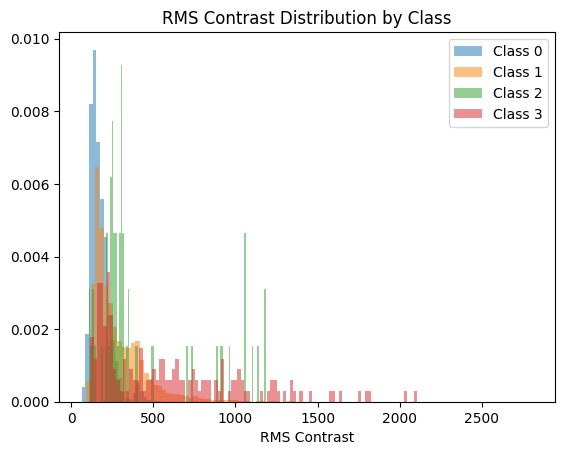

In [97]:
images_0 = data[labels == 0]  # Ensure shape is (B, C, H, W)
images_1 = data[labels == 1]  # Ensure shape is (B, C, H, W)
images_2 = data[labels == 2]  # Ensure shape is (B, C, H, W)
images_3 = data[labels == 3]  # Ensure shape is (B, C, H, W)
images_0 = torch.tensor(images_0, dtype=torch.float32).unsqueeze(1)
images_1 = torch.tensor(images_1, dtype=torch.float32).unsqueeze(1)
images_2 = torch.tensor(images_2, dtype=torch.float32).unsqueeze(1)
images_3 = torch.tensor(images_3, dtype=torch.float32).unsqueeze(1)
n_rows=1
contrast_0 = contrast_from_middle_rows(images_0,n_rows=n_rows)
contrast_1 = contrast_from_middle_rows(images_1,n_rows=n_rows)
contrast_2 = contrast_from_middle_rows(images_2,n_rows=n_rows)
contrast_3 = contrast_from_middle_rows(images_3,n_rows=n_rows)
import matplotlib.pyplot as plt
plt.hist(contrast_0.numpy(), bins=100, alpha=0.5, label='Class 0',density=True)
plt.hist(contrast_1.numpy(), bins=100, alpha=0.5, label='Class 1',density=True)
plt.hist(contrast_2.numpy(), bins=100, alpha=0.5, label='Class 2',density=True)
plt.hist(contrast_3.numpy(), bins=100, alpha=0.5, label='Class 3',density=True)
plt.xlabel('RMS Contrast')
plt.title('RMS Contrast Distribution by Class')
plt.legend()
plt.savefig("rms_contrast_distribution.png")
plt.show()

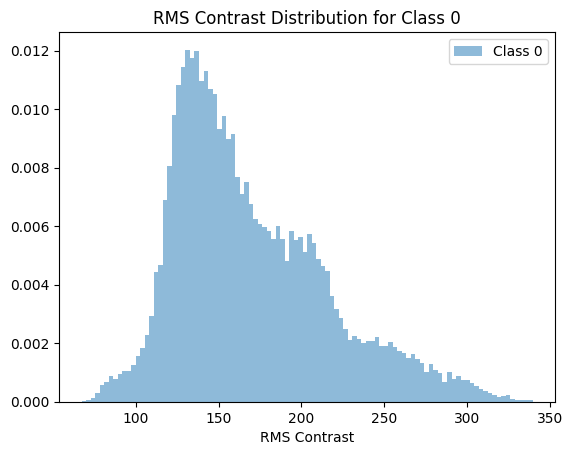

In [5]:
a=(contrast_0-contrast_0.mean())+76
plt.hist(contrast_0[contrast_0<340], bins=100, alpha=0.5, label='Class 0',density=True)
plt.xlabel('RMS Contrast')
plt.title('RMS Contrast Distribution for Class 0')
plt.legend()
plt.show()

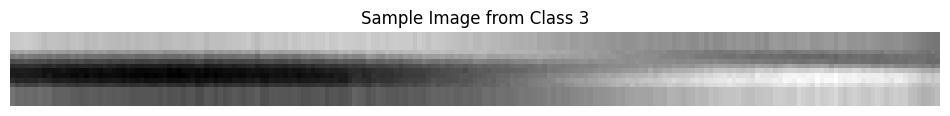

In [98]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.imshow(images_3[85,0, :, :], cmap='gray')
ax.set_title('Sample Image from Class 3')
ax.axis('off')
plt.show()


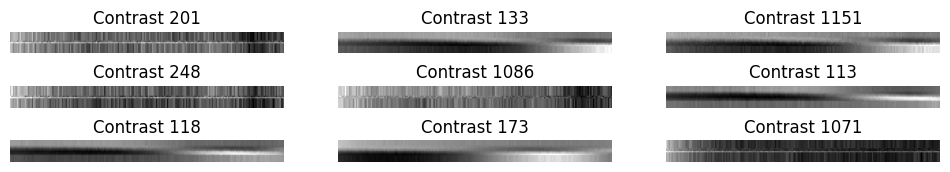

In [125]:
num_sample_images = 9
fig, axes = plt.subplots(num_sample_images // 3, 3, figsize=(12, 2))

for i in range(num_sample_images):
    ax = axes[i // 3, i % 3]
    ax.imshow(images_3[i, 0, :, :], cmap='gray')
    ax.set_title(f'Contrast {round(contrast_from_middle_rows(images_2[i, :, :].unsqueeze(0)).item())}')
    ax.axis('off')

# plt.subplots_adjust(wspace=0.1, hspace=0.05)  # Reduce space between plots
plt.show()

In [105]:
a=images_3[0, :, :].unsqueeze(0)
b=images_3[100, :, :].unsqueeze(0)
c= images_3[150, :, :].unsqueeze(0)
d= images_3[21, :, :].unsqueeze(0)
e= images_3[85, :, :].unsqueeze(0)
out= (round(contrast_from_middle_rows(i).item()) for i in [a,b,c,d,e])
print(*out)

115 767 1101 259 1277


In [13]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# # Assuming you have 4 images (grayscale) as numpy arrays of shape (h, w)
# # Example: image1, image2, image3, image4
# images = [images_1, images_2, images_3, images_0]
# all_pixels = np.concatenate([image.flatten(start_dim=1).numpy() for image in images])
# kmeans = KMeans(n_clusters=4, random_state=42)
# labels = kmeans.fit_predict(all_pixels)

In [197]:
X= (data-data.mean())/ data.std()

In [239]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
X= (data-data.mean())/ data.std()
X= X[(labels == 0) | (labels == 1)] 
contrasts = contrast_from_middle_rows(torch.tensor(X, dtype=torch.float32).unsqueeze(1), n_rows=2).numpy()
X=X[:,6:10,:].reshape(X.shape[0], -1)
X = np.concatenate((X, contrasts.reshape(-1, 1)), axis=1)  # Add contrast as a feature
# X = (X-X.mean())/ X.std()  # Normalize the data
kmeans = KMeans(n_clusters=2, random_state=1,algorithm='elkan', n_init=10, max_iter=300)
kmeans_labels = kmeans.fit_predict(X)

In [240]:
uniques, counts = np.unique(labels, return_counts=True)
print(uniques, counts)

[0 1 2 3] [32462  8659    60   169]


In [235]:
sum(counts)

41350

In [241]:
uniques, counts = np.unique(kmeans_labels, return_counts=True)
print(uniques, counts)

[0 1] [20587 20534]


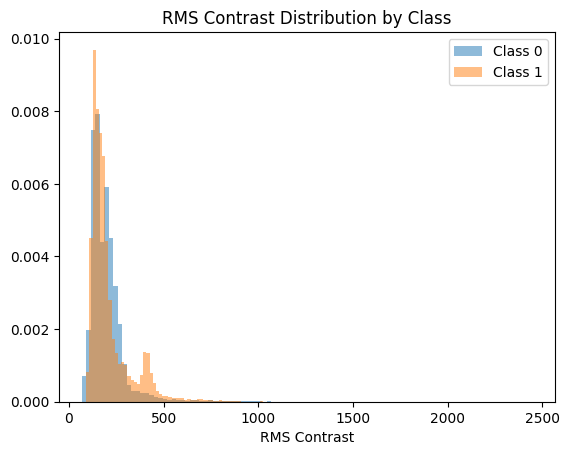

In [249]:
images_0 = (data[(labels == 0) | (labels == 1)])[kmeans_labels == 0]  # Ensure shape is (B, C, H, W)
images_1 = (data[(labels == 0) | (labels == 1)])[kmeans_labels == 1]  # Ensure shape is (B, C, H, W)
# images_2 = data[kmeans_labels == 2]  # Ensure shape is (B, C, H, W)
# images_3 = data[kmeans_labels == 3]  # Ensure shape is (B, C, H, W)
images_0 = torch.tensor(images_0, dtype=torch.float32).unsqueeze(1)
images_1 = torch.tensor(images_1, dtype=torch.float32).unsqueeze(1)
# images_2 = torch.tensor(images_2, dtype=torch.float32).unsqueeze(1)
# images_3 = torch.tensor(images_3, dtype=torch.float32).unsqueeze(1)
contrast_0 = contrast_from_middle_rows(images_0)
contrast_1 = contrast_from_middle_rows(images_1)
# contrast_2 = contrast_from_middle_rows(images_2)
# contrast_3 = contrast_from_middle_rows(images_3)
import matplotlib.pyplot as plt
plt.hist(contrast_0.numpy(), bins=100, alpha=0.5, label='Class 0',density=True)
plt.hist(contrast_1.numpy(), bins=100, alpha=0.5, label='Class 1',density=True)
# plt.hist(contrast_2.numpy(), bins=100, alpha=0.5, label='Class 2',density=True)
# plt.hist(contrast_3.numpy(), bins=100, alpha=0.5, label='Class 3',density=True)
plt.xlabel('RMS Contrast')
plt.title('RMS Contrast Distribution by Class')
plt.legend()
plt.savefig("rms_contrast_distribution.png")
plt.show()

In [251]:
uniques, counts = np.unique(kmeans_labels[labels == 1], return_counts=True)
print(uniques, counts)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 41121 but corresponding boolean dimension is 41350

In [250]:
s=(data[(labels == 0) | (labels == 1)])[(labels == 1) & (kmeans_labels == 0)]
num_sample_images = 9
fig, axes = plt.subplots(num_sample_images // 3, 3, figsize=(12, 2))

for i in range(num_sample_images):
    ax = axes[i // 3, i % 3]
    ax.imshow(s[i, :, :], cmap='gray')
    ax.set_title(f'Contrast {round(contrast_from_middle_rows(torch.tensor(s[i, :, :]).unsqueeze(0).unsqueeze(0)).item())}')
    ax.axis('off')

# plt.subplots_adjust(wspace=0.1, hspace=0.05)  # Reduce space between plots
plt.show()

ValueError: operands could not be broadcast together with shapes (41350,) (41121,) 